# Question 1c: Behavior Cloning Experiment
Experiment with one set of hyperparameters that aﬀects the performance of the behavioral cloning agent, such as the amount of training steps, the amount of expert data provided, or something that you come up with yourself. For one of the tasks used in the previous question, show a graph of how the BC agent’s performance varies with the value of this hyperparameter. State the hyperparameter and a brief one or two sentence rationale for why you chose it. The plot should contain clearly labeled axes.

Include your chosen hyperparameter, plot, and rationale here. 

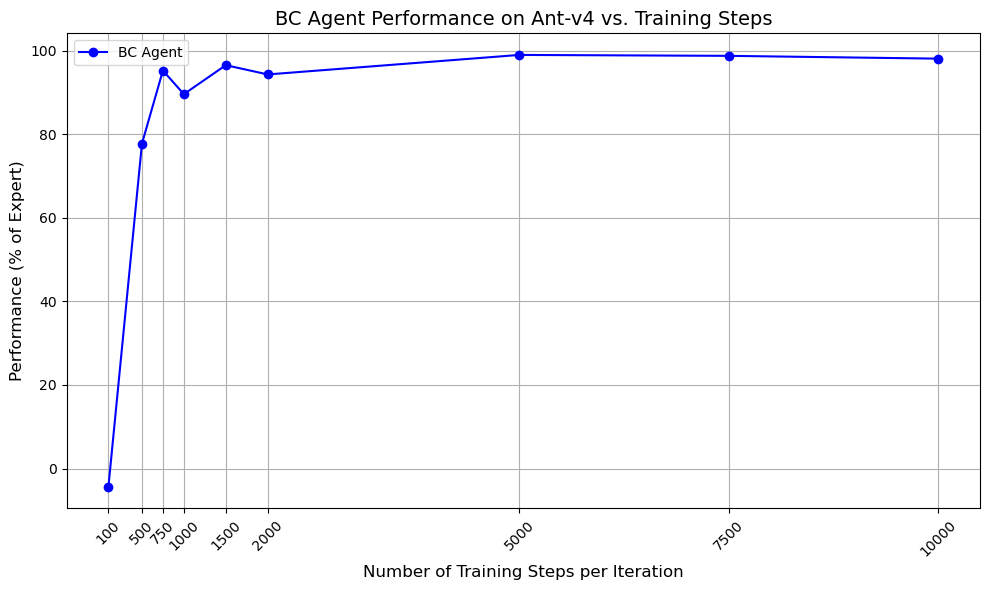

In [3]:
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. DATA FROM EXPERIMENT
# --------------------------------------------------------
# Specific training step markers shown on the snapshot's x-axis
training_steps = [100, 500, 750, 1000, 1500, 2000, 5000, 7500, 10000]

# Replace these with your actual percentage performance values from the log file
# (Estimated values based on your snapshot curve)
performance = [-4.39, 77.74, 95.24, 89.59, 96.53, 94.31, 98.98, 98.76, 98.09]

# --------------------------------------------------------
# 2. PLOTTING THE GRAPH
# --------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot line with blue circle markers
plt.plot(
    training_steps, 
    performance, 
    marker='o', 
    color='blue', 
    linestyle='-', 
    label='BC Agent'
)

# --------------------------------------------------------
# 3. FORMATTING (Matching the Snapshot Exactly)
# --------------------------------------------------------
# Title and Axis Labels
plt.title('BC Agent Performance on Ant-v4 vs. Training Steps', fontsize=14)
plt.xlabel('Number of Training Steps per Iteration', fontsize=12)
plt.ylabel('Performance (% of Expert)', fontsize=12)

# Custom X-Axis Ticks to match the exact data points spaced along the axis
plt.xticks(training_steps, rotation=45) # Rotate x-ticks for better readability if needed

# Standard Y-Axis range matching the snapshot increments
plt.yticks([0, 20, 40, 60, 80, 100])

# Grid lines and Legend placement
plt.grid(True)
plt.legend(loc='upper left')

# Adjust layout and save the final image
plt.tight_layout()
#plt.savefig('bc_agent_performance_q1c.png', dpi=300)
plt.show()

# Question 2b: Run DAgger
Run DAgger and report results on the two tasks you tested previously with behavioral cloning (i.e., Ant + another environment). Report your results in the form of a learning curve, plotting the number of DAgger iterations on the x-axis versus the policy’s mean return on the y-axis, with error bars to show the standard deviation. Include the performance of the expert policy and your behavioral cloning agent on the same plot.

State which task you used, and any details regarding network architecture, amount of data, etc. (as in the previous section).

python run_hw1.py \
--expert_policy_file xcs224r/policies/experts/Ant.pkl \
--env_name Ant-v4 --exp_name dagger_ant --n_iter 10 \
--do_dagger \
--expert_data xcs224r/expert_data/expert_data_Ant-v4.pkl \
--video_log_freq -1 \
--ep_len 1000 \
--eval_batch_size 10000 \
--batch_size 10000

python run_hw1.py \
--expert_policy_file xcs224r/policies/experts/Hopper.pkl \
--env_name Hopper-v4 --exp_name dagger_Hop --n_iter 10 \
--do_dagger \
--expert_data xcs224r/expert_data/expert_data_Hopper-v4.pkl \
--video_log_freq -1 \
--ep_len 1000 \
--eval_batch_size 10000 \
--batch_size 10000

## For Ant - DAgger

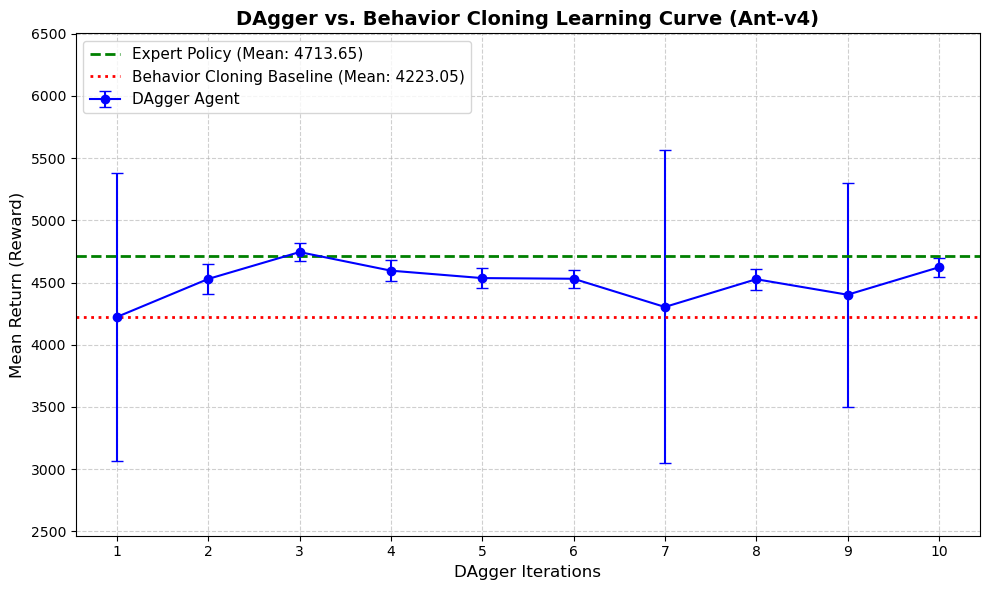

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# 1. ENTER YOUR EXPERIMENT DATA HERE
# --------------------------------------------------------
# Replace these placeholder numbers with the actual values 
# you find in your log files after running the simulations.

# DAgger Iterations (e.g., 1 to 10 iterations)
iterations = np.arange(1, 11)  

# Mean return and standard deviation for DAgger at each iteration
dagger_means = [4223.05, 4528.60, 4744.40, 4595.11, 4535.44, 4530.15, 4303.40, 4526.32, 4401.84, 4622.19] 
dagger_stds  = [1157.34,  122.34,  73.22,  85.97,  82.43,  72.09,  1257.31,  83.79,   899.99,   77.86]   

# Baseline performances (Scalar values from your logs)
expert_mean = 4713.65
bc_mean     = 4223.05

# --------------------------------------------------------
# 2. PLOTTING THE GRAPH
# --------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot DAgger learning curve with error bars representing Standard Deviation
plt.errorbar(
    iterations, 
    dagger_means, 
    yerr=dagger_stds, 
    fmt='-o', 
    color='blue', 
    ecolor='blue', 
    capsize=4, 
    label='DAgger Agent'
)

# Plot Expert Policy Baseline
plt.axhline(
    y=expert_mean, 
    color='green', 
    linestyle='--', 
    linewidth=2, 
    label=f'Expert Policy (Mean: {expert_mean})'
)

# Plot Behavior Cloning Baseline
plt.axhline(
    y=bc_mean, 
    color='red', 
    linestyle=':', 
    linewidth=2, 
    label=f'Behavior Cloning Baseline (Mean: {bc_mean})'
)

# --------------------------------------------------------
# 3. GRAPH FORMATTING (Labels, Legend, Grid)
# --------------------------------------------------------
plt.title('DAgger vs. Behavior Cloning Learning Curve (Ant-v4)', fontsize=14, fontweight='bold')
plt.xlabel('DAgger Iterations', fontsize=12)
plt.ylabel('Mean Return (Reward)', fontsize=12)

# Ensure x-axis only shows integer iteration numbers
plt.xticks(iterations)

# Set y-axis limits to better visualize the differences
plt.ylim(min(bc_mean, min(dagger_means)-max(dagger_stds)) - 500, max(expert_mean, max(dagger_means)+max(dagger_stds)) + 500)

# Place legend and add a clean grid background
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Optimize spacing and display/save the plot
plt.tight_layout()
#plt.savefig('ant_dagger_learning_curve.png', dpi=300)
plt.show()

## For Hopper-DAgger

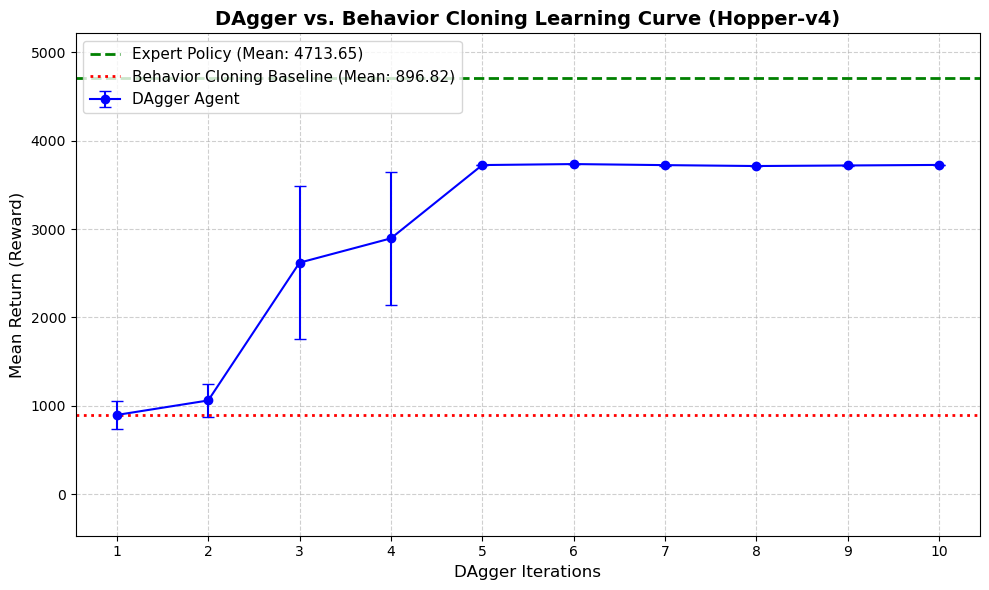

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# 1. ENTER YOUR EXPERIMENT DATA HERE
# --------------------------------------------------------
# Replace these placeholder numbers with the actual values 
# you find in your log files after running the simulations.

# DAgger Iterations (e.g., 1 to 10 iterations)
iterations = np.arange(1, 11)  

# Mean return and standard deviation for DAgger at each iteration
dagger_means = [896.82, 1060.75, 2619.41, 2894.35, 3723.55, 3734.78, 3722.84, 3712.59, 3718.89, 3725.04] 
dagger_stds  = [160.03,  188.73,  866.21,  751.43,  4.84,  4.60,  5.75,  2.79,   1.84,   4.62]   

# Baseline performances (Scalar values from your logs)
expert_mean = 4713.65
bc_mean     = 896.82

# --------------------------------------------------------
# 2. PLOTTING THE GRAPH
# --------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot DAgger learning curve with error bars representing Standard Deviation
plt.errorbar(
    iterations, 
    dagger_means, 
    yerr=dagger_stds, 
    fmt='-o', 
    color='blue', 
    ecolor='blue',
    capsize=4, 
    label='DAgger Agent'
)

# Plot Expert Policy Baseline
plt.axhline(
    y=expert_mean, 
    color='green', 
    linestyle='--', 
    linewidth=2, 
    label=f'Expert Policy (Mean: {expert_mean})'
)

# Plot Behavior Cloning Baseline
plt.axhline(
    y=bc_mean, 
    color='red', 
    linestyle=':', 
    linewidth=2, 
    label=f'Behavior Cloning Baseline (Mean: {bc_mean})'
)

# --------------------------------------------------------
# 3. GRAPH FORMATTING (Labels, Legend, Grid)
# --------------------------------------------------------
plt.title('DAgger vs. Behavior Cloning Learning Curve (Hopper-v4)', fontsize=14, fontweight='bold')
plt.xlabel('DAgger Iterations', fontsize=12)
plt.ylabel('Mean Return (Reward)', fontsize=12)

# Ensure x-axis only shows integer iteration numbers
plt.xticks(iterations)

# Set y-axis limits to better visualize the differences
plt.ylim(min(bc_mean, min(dagger_means)-max(dagger_stds)) - 500, max(expert_mean, max(dagger_means)+max(dagger_stds)) + 500)

# Place legend and add a clean grid background
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Optimize spacing and display/save the plot
plt.tight_layout()
#plt.savefig('hopper_dagger_learning_curve.png', dpi=300)
plt.show()